In [58]:
#### Homework 4 for the Course of Methodology and Research Methods of Political Science (Problems 3-5)
#### Author: Vsevolod Sergeevich Muronets, first year PEP student
#### Date: 27th of March 2024


import numpy as np
import pandas as pd
import os
import statsmodels as sm
from plotnine import *
np.random.seed(12345)
import statsmodels.formula.api as statf

In [2]:
### Problem 3.

from google.colab import files
uploaded = files.upload()

Saving smoke.xls to smoke.xls


In [5]:
## I.

df1 = pd.read_excel("/content/smoke.xls")

df1

,16,60.506,1,46,20000,0,0.1,9.903487,2116,4.102743
0,16.0,57.883,1,40,30000,0,0,10.308950,1600,4.058424
1,12.0,57.664,1,58,30000,3,0,10.308950,3364,4.054633
2,13.5,57.883,1,30,20000,0,0,9.903487,900,4.058424
3,10.0,58.320,1,17,20000,0,0,9.903487,289,4.065945
4,6.0,59.340,1,86,6500,0,0,8.779557,7396,4.083283
...,...,...,...,...,...,...,...,...,...,...
801,18.0,61.818,0,52,30000,20,0,10.308950,2704,4.124195
802,18.0,61.676,1,31,12500,0,0,9.433484,961,4.121895
803,16.0,60.707,1,30,20000,0,0,9.903487,900,4.106059
804,10.0,59.988,1,18,20000,0,0,9.903487,324,4.094144


In [6]:
column_names_smoke = ['educ', 'cigpric', 'white', 'age', 'income', 'cigs', 'restaurn', 'lincome', 'agesq', 'lcigpric']
data_smoke_named = pd.read_excel('/content/smoke.xls', header=None, names=column_names_smoke)

data_smoke_named

,educ,cigpric,white,age,income,cigs,restaurn,lincome,agesq,lcigpric
0,16.0,60.506,1,46,20000,0,0,9.903487,2116,4.102743
1,16.0,57.883,1,40,30000,0,0,10.308950,1600,4.058424
2,12.0,57.664,1,58,30000,3,0,10.308950,3364,4.054633
3,13.5,57.883,1,30,20000,0,0,9.903487,900,4.058424
4,10.0,58.320,1,17,20000,0,0,9.903487,289,4.065945
...,...,...,...,...,...,...,...,...,...,...
802,18.0,61.818,0,52,30000,20,0,10.308950,2704,4.124195
803,18.0,61.676,1,31,12500,0,0,9.433484,961,4.121895
804,16.0,60.707,1,30,20000,0,0,9.903487,900,4.106059
805,10.0,59.988,1,18,20000,0,0,9.903487,324,4.094144


In [ ]:
cigs0 = sum(data_smoke_named.cigs == 0)

cigs0

497

In [ ]:
cigs20 = sum(data_smoke_named.cigs == 20)

cigs20

101

In [ ]:
len(data_smoke_named)

807

In [ ]:
print("Therefore, in the sample we have 497 people who claim to not smoke at all, around 61% from the whole sample, and 101 people who claim to smoke 20 cigarettes a day, around 12% from the whole sample")

In [ ]:
print('There is a fraction of people who claim to smoke 20 cigarettes a day probably due to the fact that there are 20 cigarettes in a regular cigarette pack, so those who smoke around a pack a day tend to write 20 meaning around 20, or around pack a day')

There is a fraction of people who claim to smoke 20 cigarettes a day probably due to the fact that there are 20 cigarettes in a regular cigarette pack, so those who smoke around a pack a day tend to write 20 meaning around 20, or around pack a day


In [7]:
## II.

data_smoke_named = data_smoke_named.loc[(data_smoke_named['cigs']!='.') & (data_smoke_named['lcigpric']!='.')
                 & (data_smoke_named['lincome']!='.') & (data_smoke_named['white']!='.')
                 & (data_smoke_named['educ']!='.') & (data_smoke_named['age']!='.')
                 & (data_smoke_named['agesq']!='.')]

data_estimation_smoke = pd.DataFrame({'Intercept': [1]*len(data_smoke_named),
                                'cigs': data_smoke_named['cigs'],
                                'log_cigpric': data_smoke_named['lcigpric'],
                                'log_income': data_smoke_named['lincome'],
                                'white': data_smoke_named['white'],
                                'educ': data_smoke_named['educ'],
                                'age': data_smoke_named['age'],
                                'agesq': data_smoke_named['agesq']})
data_estimation_smoke = data_estimation_smoke.astype(float)

data_estimation_smoke.describe(include = 'all')

,Intercept,cigs,log_cigpric,log_income,white,educ,age,agesq
count,807.0,807.000000,807.000000,807.000000,807.000000,807.000000,807.000000,807.000000
mean,1.0,8.686493,4.096032,9.687315,0.878563,12.470880,41.237918,1990.135068
std,0.0,13.721516,0.082919,0.712695,0.326837,3.057161,17.027285,1577.165644
min,1.0,0.000000,3.784281,6.214608,0.000000,6.000000,17.000000,289.000000
25%,1.0,0.000000,4.062880,9.433484,1.000000,10.000000,28.000000,784.000000
50%,1.0,0.000000,4.111742,9.903487,1.000000,12.000000,38.000000,1444.000000
75%,1.0,20.000000,4.145972,10.308950,1.000000,13.500000,54.000000,2916.000000
max,1.0,80.000000,4.250336,10.308950,1.000000,18.000000,88.000000,7744.000000


In [ ]:
model_cigs = statf.poisson('cigs ~ log_cigpric + log_income + white + educ + age + agesq',
                                                      data = data_estimation_smoke)
results_cigs = model_cigs.fit()
print(results_cigs.summary())

log_likelihood_cigs = results_cigs.llf

Optimization terminated successfully.
         Current function value: 10.141302
         Iterations 12
                          Poisson Regression Results                          
Dep. Variable:                   cigs   No. Observations:                  807
Model:                        Poisson   Df Residuals:                      800
Method:                           MLE   Df Model:                            6
Date:                Tue, 12 Mar 2024   Pseudo R-squ.:                 0.05342
Time:                        16:43:29   Log-Likelihood:                -8184.0
converged:                       True   LL-Null:                       -8645.9
Covariance Type:            nonrobust   LLR p-value:                2.853e-196
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.4628      0.615      2.380      0.017       0.258       2.667
log_cigpric    -0.3553  

In [ ]:
print("According to the results of regression, all factor are significant on the 0,05 level despite racial variable (white), so that price of cigarettes affect amount of cigarettes smoked a day negatively, income - posititively (so that people have more money to spend on cigarettes), more educated people smoke less, older people - more (which makes sense since in the near past smoking was more popular than now in general), and negative squared age means that as people become older the effect of age decreases, which also makes sense because as people become older they tend to quit bad habits due to problems with health. Therefore, the coefficients make perfect sense, at least to me.")

In [8]:
## III.

model_cigs = statf.poisson('cigs ~ log_cigpric + log_income + white + educ + age + agesq',
                                                      data = data_estimation_smoke)
results_cigs_rse = model_cigs.fit(cov_type = 'HC0')
print(results_cigs_rse.summary())

log_likelihood_cigs_rse = results_cigs_rse.llf

Optimization terminated successfully.
         Current function value: 10.141302
         Iterations 12
                          Poisson Regression Results                          
Dep. Variable:                   cigs   No. Observations:                  807
Model:                        Poisson   Df Residuals:                      800
Method:                           MLE   Df Model:                            6
Date:                Wed, 27 Mar 2024   Pseudo R-squ.:                 0.05342
Time:                        17:46:29   Log-Likelihood:                -8184.0
converged:                       True   LL-Null:                       -8645.9
Covariance Type:                  HC0   LLR p-value:                2.853e-196
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.4628      3.024      0.484      0.629      -4.463       7.389
log_cigpric    -0.3553  

In [9]:
print("Robist standart errors do not change the values of coefficients, but change importance of cigarette prices, income (and white skin stays insignificant), now showing their insignificance. Insignificance of income and cigarette prices also make sense, because those who smoke probably rarely quit due to the increasing prices of cigarettes, adn with increases of income many people actually quit smoking due to a necessity of working more, getting other joys besides cigarettes and new people around them who may be against smoking.")

Robist standart errors do not change the values of coefficients, but change importance of cigarette prices, income (and white skin stays insignificant), now showing their insignificance. Insignificance of income and cigarette prices also make sense, because those who smoke probably rarely quit due to the increasing prices of cigarettes, adn with increases of income many people actually quit smoking due to a necessity of working more, getting other joys besides cigarettes and new people around them who may be against smoking.


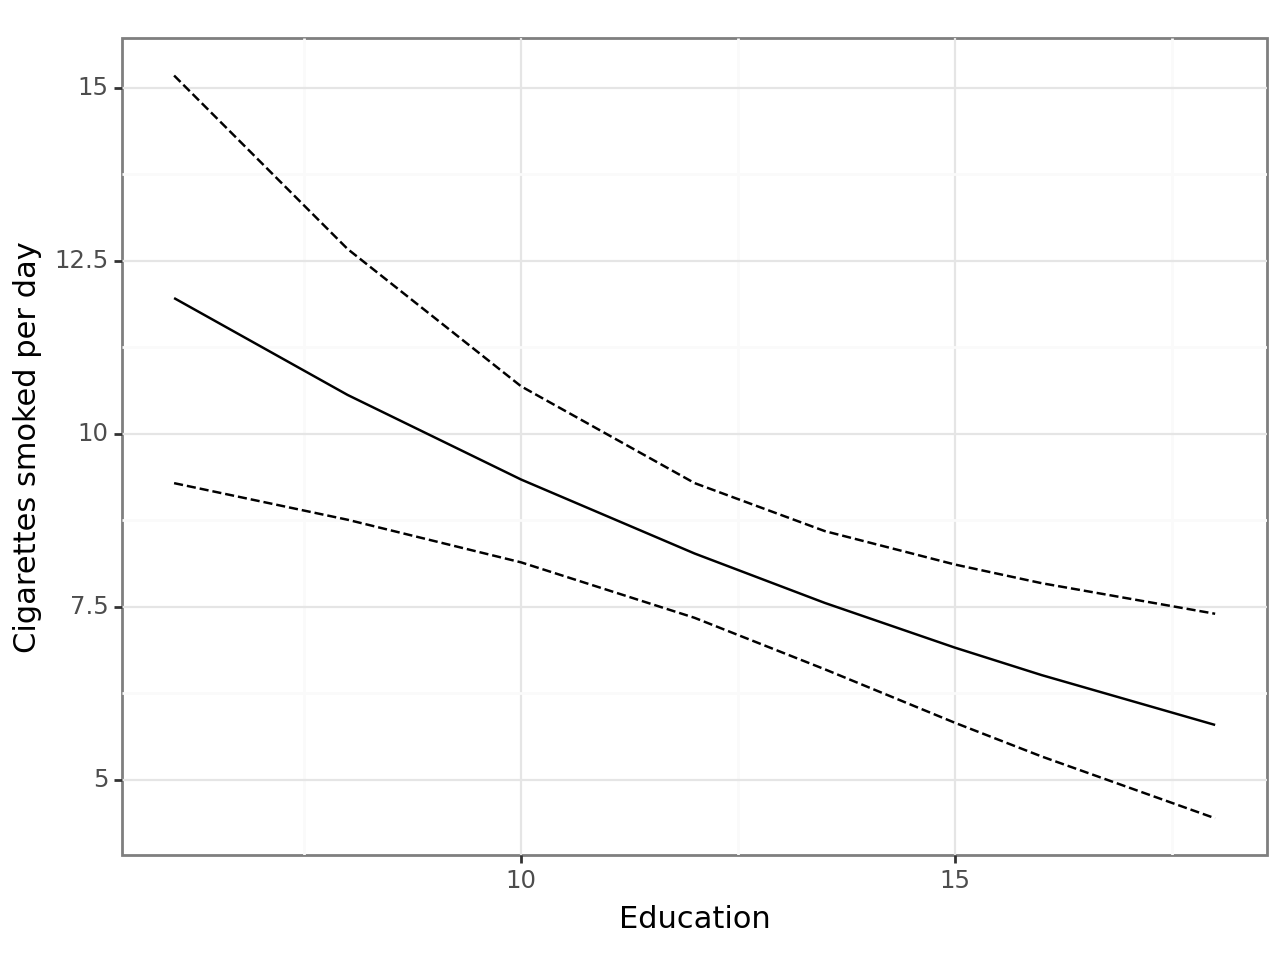

<Figure Size: (640 x 480)>

In [ ]:
## IV.

variance_covariance = results_cigs_rse.cov_params()

coef_distribution = np.random.multivariate_normal(results_cigs_rse.params,variance_covariance,size=10000)
binary_variables = ['white']
continuous_variables = ['log_cigpric', 'log_income', 'age', 'agesq']

data_plot_cigs = data_estimation_smoke[['Intercept', 'log_cigpric', 'log_income', 'white', 'educ', 'age', 'agesq']].copy()
for x in binary_variables:
    mean_value = np.mean(data_plot_cigs[x])
    if mean_value >=0.5:
        data_plot_cigs[x] = 1
    else:
        data_plot_cigs[x] = 0
for x in continuous_variables:
    data_plot_cigs[x] = np.mean(data_plot_cigs[x])

matrix_score = np.exp(np.dot(data_plot_cigs, np.transpose(coef_distribution)))
cigarettes_smoked = np.mean(matrix_score, axis = 1)
upper_bound = np.percentile(matrix_score, axis = 1, q = 97.5)
lower_bound = np.percentile(matrix_score, axis = 1, q = 2.5)
data_illustration = pd.DataFrame({'Education': data_plot_cigs['educ'],
                                  'Predicted Counts': cigarettes_smoked,
                                  'Upper Bound': upper_bound,
                                  'Lower Bound': lower_bound})
plot = (ggplot(data_illustration, aes(x = 'Education'))+
        geom_line(aes(y = 'Predicted Counts'), linetype = 'solid', colour = 'black') +
        geom_line(aes(y = 'Upper Bound'), linetype = 'dashed', colour = 'black') +
        geom_line(aes(y = 'Lower Bound'), linetype = 'dashed', colour = 'black') +
        theme_bw()+
        ylab('Cigarettes smoked per day'))
plot


In [11]:
## V.

print("With higher level of education people may receive more knowledge about dangers of smoking, have less time to smoke, and find new ways to experience joy besides smoking. Also, countries where people receive full school education, college and university education are generally richer countries, and restrictions on smoking may be more strict in such countries. Therefore, amount of cigarettes smoked per day decreasing with growing number of years of education makes perfect sense.")

With higher level of education people may receive more knowledge about dangers of smoking, have less time to smoke, and find new ways to experience joy besides smoking. Also, countries where people receive full school education, college and university education are generally richer countries, and restrictions on smoking may be more strict in such countries. Therefore, amount of cigarettes smoked per day decreasing with growing number of years of education makes perfect sense.


In [10]:
### Problem 4

from google.colab import files
uploaded = files.upload()

Saving scobit.dta to scobit.dta


In [12]:
scobit = pd.read_stata("/content/scobit.dta")

scobit

,state,vote,age,educ,citizen,rweight,south,gov,closing,age2,educ2,cloeduc,cloeduc2,newvote,newage,neweduc
0,93.0,1.0,60.0,13.0,1.0,207134.0,0.0,0.0,29.0,3600.0,25.0,145.0,725.0,1.0,0.0,5.0
1,93.0,1.0,80.0,13.0,1.0,215836.0,0.0,0.0,29.0,6400.0,25.0,145.0,725.0,1.0,0.0,5.0
2,93.0,2.0,32.0,13.0,1.0,184639.0,0.0,0.0,29.0,1024.0,25.0,145.0,725.0,0.0,0.0,5.0
3,93.0,1.0,25.0,13.0,1.0,184883.0,0.0,0.0,29.0,625.0,25.0,145.0,725.0,1.0,0.0,5.0
4,93.0,1.0,55.0,11.0,1.0,168557.0,0.0,0.0,29.0,3025.0,16.0,116.0,464.0,1.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99671,94.0,1.0,53.0,1.0,1.0,18138.0,0.0,0.0,30.0,2809.0,1.0,30.0,30.0,1.0,0.0,1.0
99672,94.0,1.0,29.0,13.0,1.0,17621.0,0.0,0.0,30.0,841.0,25.0,150.0,750.0,1.0,0.0,5.0
99673,94.0,1.0,28.0,13.0,1.0,17246.0,0.0,0.0,30.0,784.0,25.0,150.0,750.0,1.0,0.0,5.0
99674,94.0,2.0,24.0,13.0,1.0,16089.0,0.0,0.0,30.0,576.0,25.0,150.0,750.0,0.0,0.0,5.0


In [13]:
scobit = scobit.loc[(scobit['newvote']!='.') & (scobit['closing']!='.')
                 & (scobit['neweduc']!='.') & (scobit['age']!='.')
                 & (scobit['south']!='.') & (scobit['gov']!='.')]

data_estimation_scobit = pd.DataFrame({'Intercept':[1]*len(scobit),
                                'newvote': scobit['newvote'],
                                'closing': scobit['closing'],
                                'neweduc': scobit['neweduc'],
                                'age': scobit['age'],
                                'south': scobit['south'],
                                'gov': scobit['gov']})

data_estimation_scobit = data_estimation_scobit.astype(float)

data_estimation_scobit.describe(include = 'all')

,Intercept,newvote,closing,neweduc,age,south,gov
count,99676.0,99676.000000,99676.000000,99676.000000,99676.000000,99676.000000,99676.000000
mean,1.0,0.670101,24.790752,5.275904,43.813877,0.192614,0.174114
std,0.0,0.470179,10.135645,1.457504,18.069573,0.394354,0.379209
min,1.0,0.000000,0.000000,1.000000,18.000000,0.000000,0.000000
25%,1.0,0.000000,21.000000,5.000000,28.000000,0.000000,0.000000
50%,1.0,1.000000,30.000000,5.000000,40.000000,0.000000,0.000000
75%,1.0,1.000000,30.000000,6.000000,58.000000,0.000000,0.000000
max,1.0,1.000000,50.000000,8.000000,99.000000,1.000000,1.000000


In [14]:
## I.

model_scobit = sm.discrete.discrete_model.Probit.from_formula('newvote ~ closing + neweduc + age + south + gov',
                                                      data = data_estimation_scobit)
results_scobit = model_scobit.fit(method = 'lbfgs', maxiter = 1000)
print(results_scobit.summary())

                          Probit Regression Results                           
Dep. Variable:                newvote   No. Observations:                99676
Model:                         Probit   Df Residuals:                    99670
Method:                           MLE   Df Model:                            5
Date:                Wed, 27 Mar 2024   Pseudo R-squ.:                  0.1053
Time:                        18:03:17   Log-Likelihood:                -56550.
converged:                       True   LL-Null:                       -63205.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.9476      0.027    -72.039      0.000      -2.001      -1.895
closing       -0.0074      0.000    -16.969      0.000      -0.008      -0.007
neweduc        0.3194      0.003     94.016      0.0

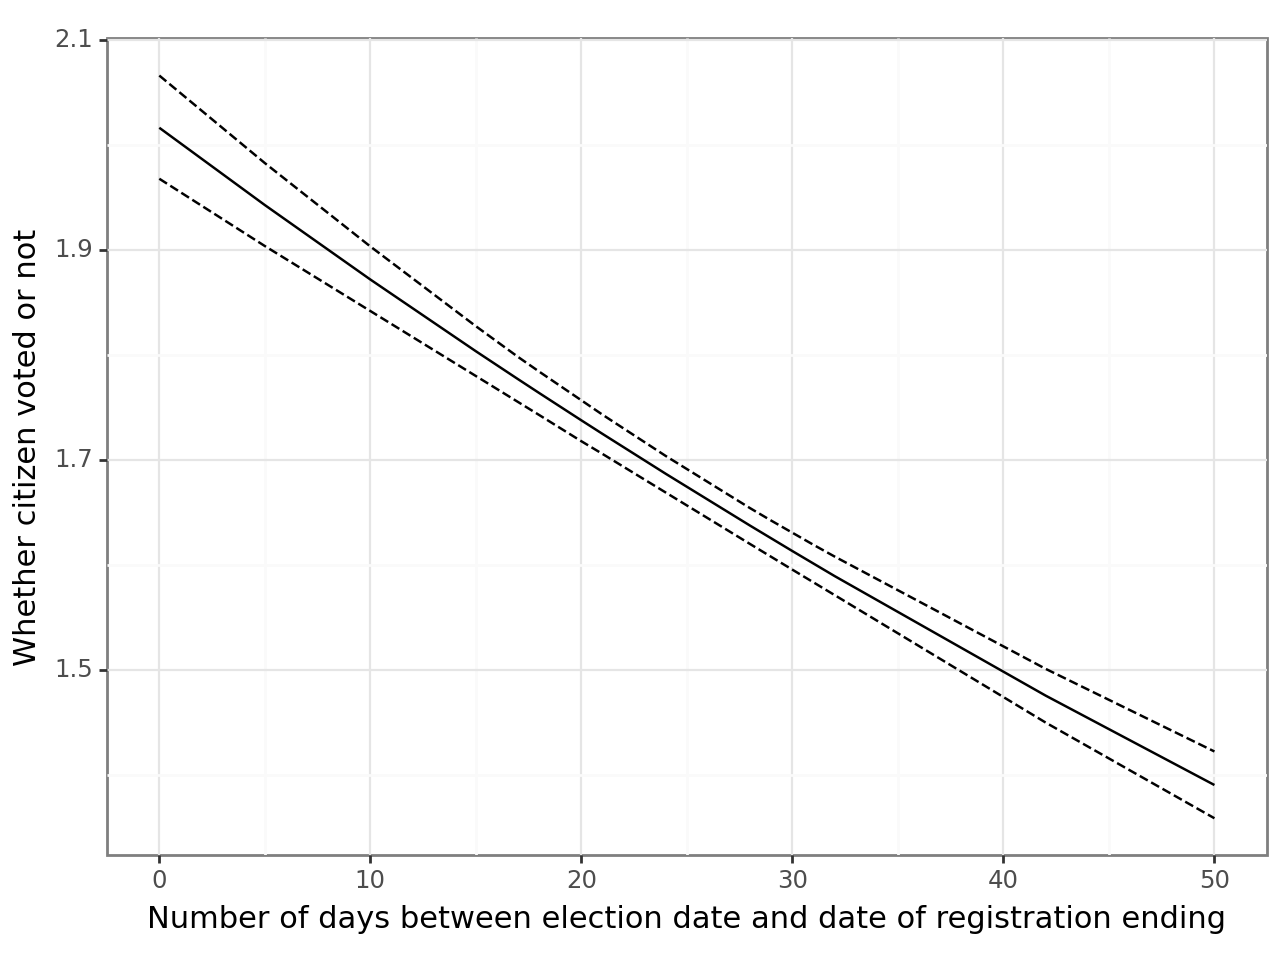

<Figure Size: (640 x 480)>

In [15]:
## II.

variance_covariance_closing = results_scobit.cov_params()

coef_distribution_closing = np.random.multivariate_normal(results_scobit.params,variance_covariance_closing,size=1000) # It would be more correct to use size=10000 here, but in such a case more RAM that was available
# on my computers would be needed (my sessions "crashed" if I used size of 10000).
binary_variables_closing = ['south', 'gov']
continuous_variables_closing = ['neweduc', 'age']

data_plot_closing = data_estimation_scobit[['Intercept', 'closing', 'neweduc', 'age', 'south', 'gov']].copy()
for x in binary_variables_closing:
    mean_value_closing = np.mean(data_plot_closing[x])
    if mean_value_closing >=0.5:
        data_plot_closing[x] = 1
    else:
        data_plot_closing[x] = 0
for x in continuous_variables_closing:
    data_plot_closing[x] = np.mean(data_plot_closing[x])

matrix_score_closing = np.exp(np.dot(data_plot_closing, np.transpose(coef_distribution_closing)))
vote = np.mean(matrix_score_closing, axis = 1)
upper_bound_closing = np.percentile(matrix_score_closing, axis = 1, q = 97.5)
lower_bound_closing = np.percentile(matrix_score_closing, axis = 1, q = 2.5)
data_illustration_closing = pd.DataFrame({'Number of days between election date and date of registration ending': data_plot_closing['closing'],
                                  'Predicted Counts': vote,
                                  'Upper Bound': upper_bound_closing,
                                  'Lower Bound': lower_bound_closing})
plot_closing = (ggplot(data_illustration_closing, aes(x = 'Number of days between election date and date of registration ending'))+
        geom_line(aes(y = 'Predicted Counts'), linetype = 'solid', colour = 'black') +
        geom_line(aes(y = 'Upper Bound'), linetype = 'dashed', colour = 'black') +
        geom_line(aes(y = 'Lower Bound'), linetype = 'dashed', colour = 'black') +
        theme_bw()+
        ylab('Whether citizen voted or not'))
plot_closing


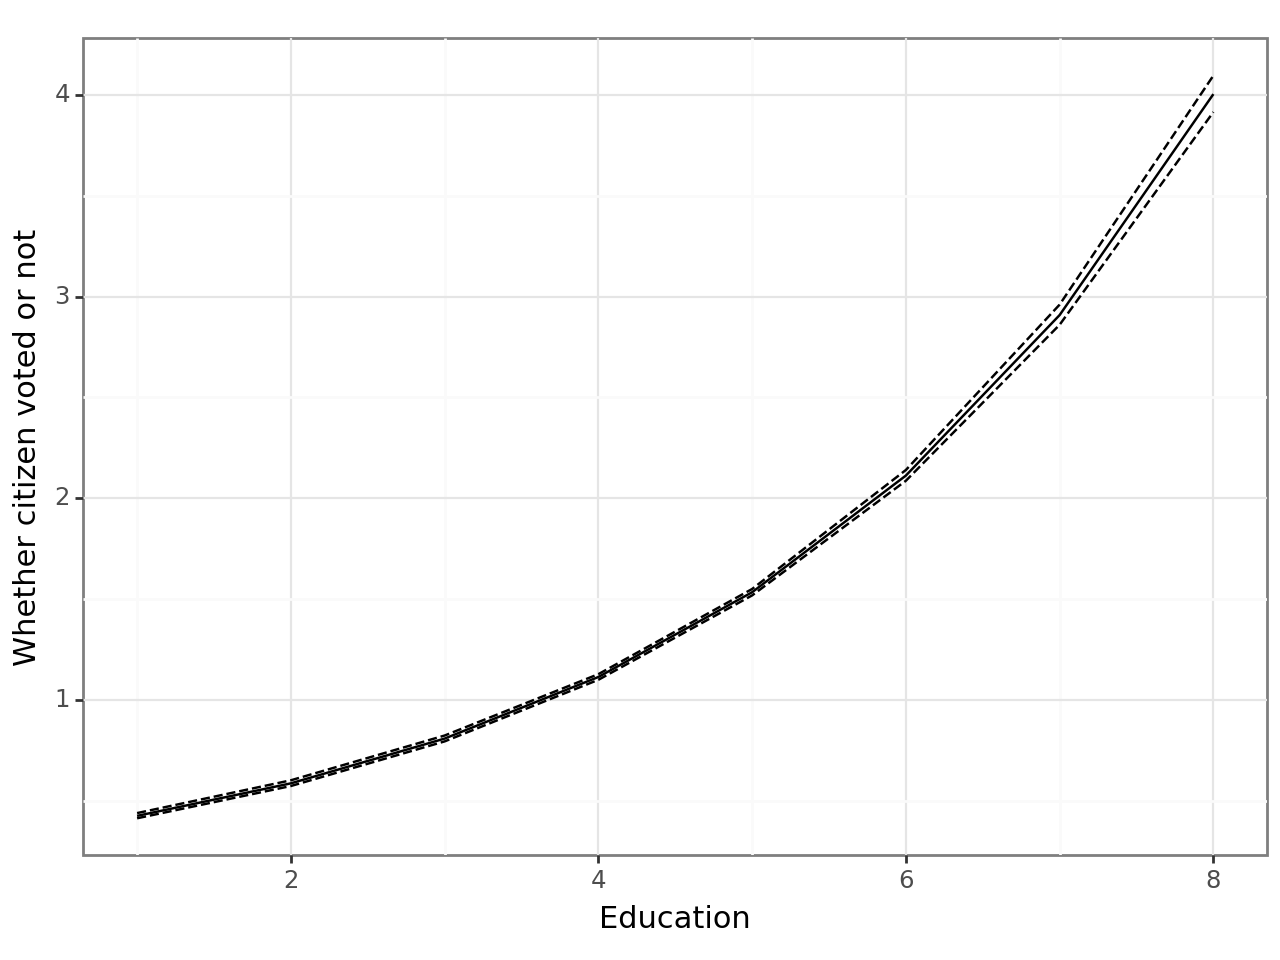

<Figure Size: (640 x 480)>

In [16]:
## III.

variance_covariance_neweduc = results_scobit.cov_params()

coef_distribution_neweduc = np.random.multivariate_normal(results_scobit.params,variance_covariance_neweduc,size=1000)
binary_variables_neweduc = ['south', 'gov']
continuous_variables_neweduc = ['closing', 'age']

data_plot_neweduc = data_estimation_scobit[['Intercept', 'closing', 'neweduc', 'age', 'south', 'gov']].copy()
for x in binary_variables_neweduc:
    mean_value_neweduc = np.mean(data_plot_neweduc[x])
    if mean_value_neweduc >=0.5:
        data_plot_neweduc[x] = 1
    else:
        data_plot_neweduc[x] = 0
for x in continuous_variables_neweduc:
    data_plot_neweduc[x] = np.mean(data_plot_neweduc[x])

matrix_score_neweduc = np.exp(np.dot(data_plot_neweduc, np.transpose(coef_distribution_neweduc)))
vote = np.mean(matrix_score_neweduc, axis = 1)
upper_bound_neweduc = np.percentile(matrix_score_neweduc, axis = 1, q = 97.5)
lower_bound_neweduc = np.percentile(matrix_score_neweduc, axis = 1, q = 2.5)
data_illustration_neweduc = pd.DataFrame({'Education': data_plot_neweduc['neweduc'],
                                  'Predicted Counts': vote,
                                  'Upper Bound': upper_bound_neweduc,
                                  'Lower Bound': lower_bound_neweduc})
plot_neweduc = (ggplot(data_illustration_neweduc, aes(x = 'Education'))+
        geom_line(aes(y = 'Predicted Counts'), linetype = 'solid', colour = 'black') +
        geom_line(aes(y = 'Upper Bound'), linetype = 'dashed', colour = 'black') +
        geom_line(aes(y = 'Lower Bound'), linetype = 'dashed', colour = 'black') +
        theme_bw()+
        ylab('Whether citizen voted or not'))
plot_neweduc

In [ ]:
## IV.

model_scobit_intterm = sm.discrete.discrete_model.Probit.from_formula('newvote ~ closing + neweduc + age + south + gov + closing:neweduc',
                                                      data = data_estimation_scobit)
results_scobit_intterm = model_scobit_intterm.fit(method = 'lbfgs', maxiter = 1000)
print(results_scobit_intterm.summary())

                          Probit Regression Results                           
Dep. Variable:                newvote   No. Observations:                99676
Model:                         Probit   Df Residuals:                    99669
Method:                           MLE   Df Model:                            6
Date:                Wed, 27 Mar 2024   Pseudo R-squ.:                  0.1053
Time:                        14:29:38   Log-Likelihood:                -56547.
converged:                       True   LL-Null:                       -63205.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -2.0341      0.051    -40.160      0.000      -2.133      -1.935
closing            -0.0041      0.002     -2.368      0.018      -0.007      -0.001
neweduc             0.3363      

In [ ]:
print("Probably, people with higher levels of education are more punctual and responsible in terms of voting, so they are more forward-looking, understand the importance of voting better, and bigger difference between election date and date of ending of registration (that is, how early one needs to complete registration) does not affect their registration and, therefore, voting as much as for those with lower levels of education.")

In [17]:
### Problem 5

# Step 0 - reproducing the results present in the session

from google.colab import files
uploaded = files.upload()

Saving assignment4.csv to assignment4.csv


In [31]:
assignment4 = pd.read_csv("/content/assignment4.csv")

assignment4

,country,year,PHYSINT,DISAP,KILL,POLPRIS,TORT,OLD_EMPINX,NEW_EMPINX,ASSN,...,aid_military,small_conflict,large_conflict,re_elect,reg_turnover,irregular_turnover,IMF_dummy,access,inflowremittance,RemittancesasashareofGDPin
0,United States of America,2000,7.0,2.0,2.0,2.0,1.0,9.0,12.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,4400.000000,NaN
1,United States,2001,5.0,2.0,2.0,0.0,1.0,9.0,12.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN,4510.000000,NaN
2,United States of America,2002,6.0,2.0,2.0,1.0,1.0,9.0,12.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,4570.000000,NaN
3,United States of America,2003,6.0,2.0,2.0,1.0,1.0,9.0,12.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,4670.000000,NaN
4,United States of America,2004,4.0,1.0,1.0,1.0,1.0,9.0,12.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,4730.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3329,Samoa,2012,7.0,2.0,2.0,2.0,1.0,NaN,9.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157.761635,NaN
3330,Samoa,2013,7.0,2.0,2.0,2.0,1.0,NaN,8.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158.029426,NaN
3331,Samoa,2014,7.0,2.0,2.0,2.0,1.0,NaN,8.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140.354490,0.175315
3332,Samoa,2015,7.0,2.0,2.0,2.0,1.0,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.526226,NaN


In [32]:
assignment4_estimation = pd.DataFrame({'Intercept': [1]*len(assignment4),
                                'log_GDP_per_Capita': np.log(assignment4['GDPpercapitacurrentUSNY']),
                                'polity': assignment4['polity2'],
                                'GDP_growth': assignment4['GDPpercapitagrowthannual'],
                                'FDI': assignment4['Foreigndirectinvestmentneti'],
                                'physint': assignment4['PHYSINT'],
                                'TradeofGDPNETRDGNFSZS': assignment4['TradeofGDPNETRDGNFSZS']})
assignment4_estimation.describe()

,Intercept,log_GDP_per_Capita,polity,GDP_growth,FDI,physint,TradeofGDPNETRDGNFSZS
count,3334.0,2557.000000,2585.000000,2561.000000,2532.000000,2809.000000,2483.000000
mean,1.0,8.129271,3.656867,2.584333,4.763611,5.050552,87.550984
std,0.0,1.613447,6.371638,5.392318,9.481449,2.263832,49.434310
min,1.0,4.663599,-10.000000,-62.214351,-79.736965,0.000000,0.308803
25%,1.0,6.802540,-2.000000,0.601126,1.257525,4.000000,56.015104
50%,1.0,8.122625,6.000000,2.506426,2.952233,5.000000,77.287537
75%,1.0,9.379019,9.000000,4.690826,5.621620,7.000000,107.631923
max,1.0,11.666615,10.000000,104.657612,255.423272,8.000000,439.656681


In [33]:
assignment4_estimation = assignment4_estimation.dropna()

assignment4_estimation

,Intercept,log_GDP_per_Capita,polity,GDP_growth,FDI,physint,TradeofGDPNETRDGNFSZS
0,1,10.503693,10.0,2.940292,3.403729,7.0,24.983181
1,1,10.526041,10.0,-0.018490,1.614327,5.0,22.803136
2,1,10.549701,10.0,0.846126,0.997184,6.0,22.149660
3,1,10.588532,10.0,1.926957,0.967329,6.0,22.450587
4,1,10.643561,10.0,2.829653,1.693509,4.0,24.294921
...,...,...,...,...,...,...,...
3225,1,8.203019,-4.0,1.985169,11.358888,6.0,121.730855
3226,1,8.378372,-4.0,-3.874653,11.040280,5.0,124.194430
3227,1,8.422941,-4.0,0.840776,6.716181,7.0,125.106748
3228,1,8.469230,-4.0,4.598181,3.770323,7.0,125.968681


In [34]:
model_asmnt4 = sm.discrete.discrete_model.MNLogit.from_formula('physint ~ log_GDP_per_Capita + polity + GDP_growth + FDI',
                                                        data = assignment4_estimation)
results_asmnt4 = model_asmnt4.fit()
print(results_asmnt4.summary())

log_likelihood_full_asmnt4 = results_asmnt4.llf

Optimization terminated successfully.
         Current function value: 1.832174
         Iterations 7
                          MNLogit Regression Results                          
Dep. Variable:                physint   No. Observations:                 2250
Model:                        MNLogit   Df Residuals:                     2210
Method:                           MLE   Df Model:                           32
Date:                Wed, 27 Mar 2024   Pseudo R-squ.:                  0.1224
Time:                        18:43:09   Log-Likelihood:                -4122.4
converged:                       True   LL-Null:                       -4697.3
Covariance Type:            nonrobust   LLR p-value:                4.081e-221
         physint=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.3065      0.829      0.370      0.712      -1.318       1.931
log_G

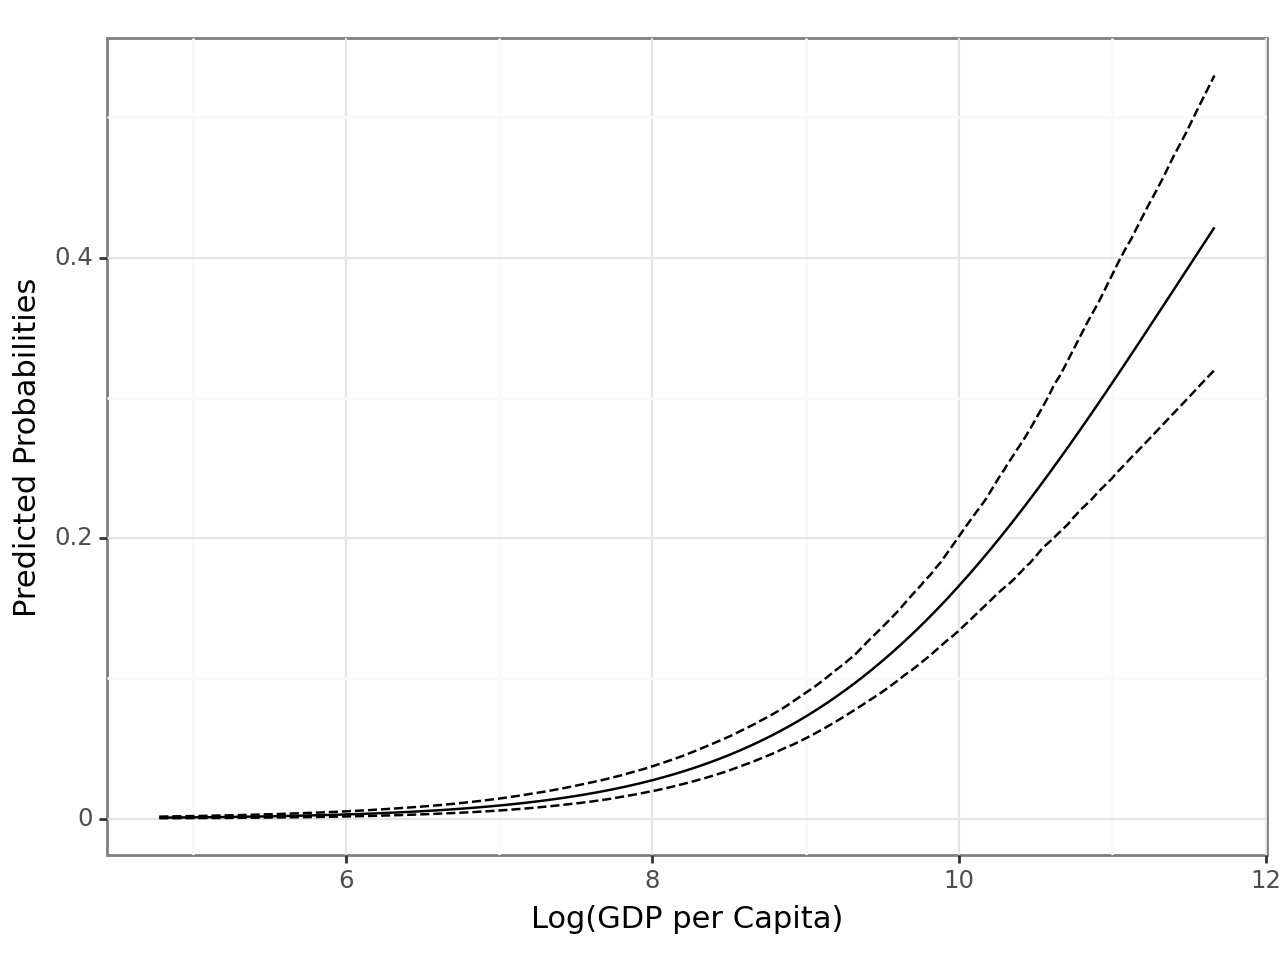

In [35]:
## I.

data_plot_asmnt4 = assignment4_estimation.copy()
data_plot_asmnt4['polity'] = np.mean(data_plot_asmnt4['polity'])
data_plot_asmnt4['GDP_growth'] = np.mean(data_plot_asmnt4['GDP_growth'])
data_plot_asmnt4['FDI'] = np.mean(data_plot_asmnt4['FDI'])

means_asmnt4 = []
for x in range(0,8):
    means_asmnt4 += [y for y in results_asmnt4.params[x]]

variance_covariance_asmnt4 = results_asmnt4.cov_params()

sample_normal_asmnt4 = np.random.multivariate_normal(means_asmnt4, variance_covariance_asmnt4, size = 1000)

coefficient_matrix_asmnt4 = np.transpose(sample_normal_asmnt4[:,0:5])
matrix_values_asmnt4 = 1 + np.exp(np.dot(data_plot_asmnt4[['Intercept', 'log_GDP_per_Capita', 'polity', 'GDP_growth', 'FDI']],
                                 coefficient_matrix_asmnt4))
for x in range(5, 36, 5):
    coefficient_matrix_asmnt4 = np.transpose(sample_normal_asmnt4[:,x:x+5])
    matrix_current_asmnt4 = np.exp(np.dot(data_plot_asmnt4[['Intercept', 'log_GDP_per_Capita', 'polity', 'GDP_growth', 'FDI']],
                                 coefficient_matrix_asmnt4))
    matrix_values_asmnt4 += matrix_current_asmnt4

coefficient_matrix_asmnt4 = np.transpose(sample_normal_asmnt4[:,35:40])
matrix_numerator_asmnt4 = np.exp(np.dot(data_plot_asmnt4[['Intercept', 'log_GDP_per_Capita', 'polity', 'GDP_growth', 'FDI']],
                                 coefficient_matrix_asmnt4))

matrix_values_final_asmnt4 = matrix_numerator_asmnt4/matrix_values_asmnt4

means_asmnt4 = np.mean(matrix_values_final_asmnt4, axis = 1)
lb_asmnt4 = np.percentile(matrix_values_final_asmnt4, q = 2.5, axis = 1)
ub_asmnt4 = np.percentile(matrix_values_final_asmnt4, q = 97.5, axis = 1)

data_plotting_asmnt4 = pd.DataFrame({'Predicted Probabilities': means_asmnt4,
                              'ub': ub_asmnt4,
                              'lb': lb_asmnt4,
                              'Log(GDP per Capita)': data_plot_asmnt4['log_GDP_per_Capita']})
plot_asmnt4 = (ggplot(data_plotting_asmnt4, aes(x = 'Log(GDP per Capita)'))+
        geom_line(aes(y = 'Predicted Probabilities'), linetype = 'solid', colour = 'black')+
        geom_line(aes(y = 'ub'), linetype = 'dashed', colour = 'black') +
        geom_line(aes(y = 'lb'), linetype = 'dashed', colour = 'black') +
        theme_bw())
print(plot_asmnt4)

In [53]:
print("Higher GDP per capita implies that Physical integrity rights protection possibility is higher, with the highest values of 8 reaching almost 0.5 in probability in richest countries (in terms of GDP per capita).")

Higher GDP per capita implies that Physical integrity rights protection possibility is higher, with the highest values of 8 reaching almost 0.5 in probability in richest countries (in terms of GDP per capita).


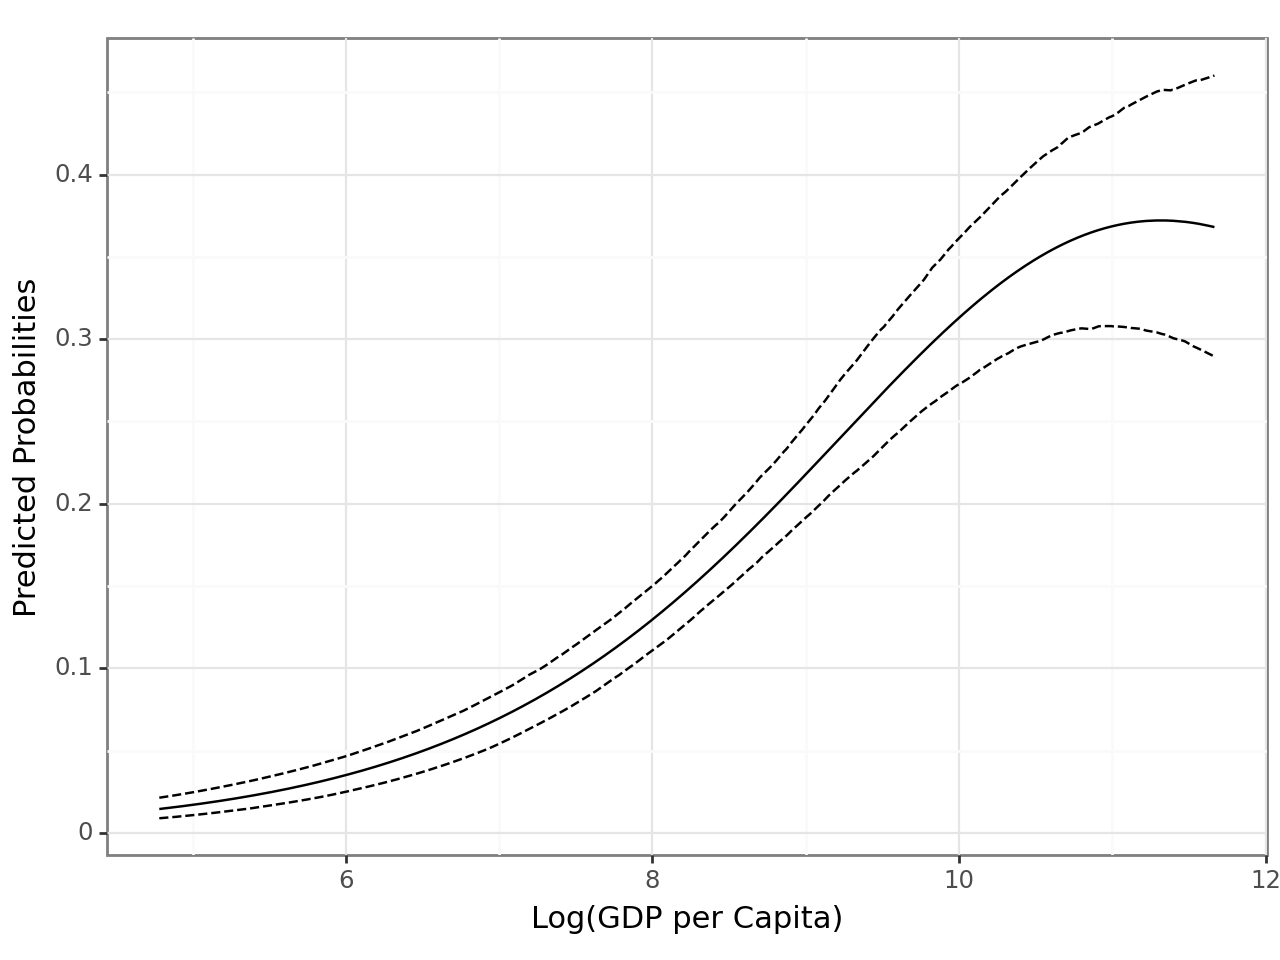

In [42]:
## II

coefficient_matrix_phys_7 = np.transpose(sample_normal_asmnt4[:,30:35])
matrix_numerator_phys_7 = np.exp(np.dot(data_plot_asmnt4[['Intercept', 'log_GDP_per_Capita', 'polity', 'GDP_growth', 'FDI']],
                                 coefficient_matrix_phys_7))

matrix_values_final_phys_7 = matrix_numerator_phys_7/matrix_values_asmnt4

means_phys_7 = np.mean(matrix_values_final_phys_7, axis = 1)
lb_phys_7 = np.percentile(matrix_values_final_phys_7, q = 2.5, axis = 1)
ub_phys_7 = np.percentile(matrix_values_final_phys_7, q = 97.5, axis = 1)

data_plotting_phys_7 = pd.DataFrame({'Predicted Probabilities': means_phys_7,
                              'ub': ub_phys_7,
                              'lb': lb_phys_7,
                              'Log(GDP per Capita)': data_plot_asmnt4['log_GDP_per_Capita']})
plot_phys_7 = (ggplot(data_plotting_phys_7, aes(x = 'Log(GDP per Capita)'))+
        geom_line(aes(y = 'Predicted Probabilities'), linetype = 'solid', colour = 'black')+
        geom_line(aes(y = 'ub'), linetype = 'dashed', colour = 'black') +
        geom_line(aes(y = 'lb'), linetype = 'dashed', colour = 'black') +
        theme_bw())
print(plot_phys_7)

In [54]:
print('After approximately value "11" for Log(GDP per capita) the probability starts to fall. This is probably due to the fact that after "11" probability for Physint = 8 is higher in countries with such measures of GDP per capita. That is, in countries with such GDP per capita situation of underprotection of physical integrity rights (Physint = 7 compared to Physint = 8) is less likely than a situation of corresponding protection on the highest (measured) level (coded as 8).')

After approximately value "11" for Log(GDP per capita) the probability starts to fall. This is probably due to the fact that after "11" probability for Physint = 8 is higher in countries with such measures of GDP per capita. That is, in countries with such GDP per capita situation of underprotection of physical integrity rights (Physint = 7 compared to Physint = 8) is less likely than a situation of corresponding protection on the highest (measured) level (coded as 8).


In [37]:
## III.

model_nogdpgrowth = sm.discrete.discrete_model.MNLogit.from_formula('physint ~ log_GDP_per_Capita + polity + FDI',
                                                        data = assignment4_estimation)
results_nogdpgrowth = model_nogdpgrowth.fit()
print(results_nogdpgrowth.summary())

log_likelihood_nogdpgrowth = results_nogdpgrowth.llf

Optimization terminated successfully.
         Current function value: 1.836961
         Iterations 7
                          MNLogit Regression Results                          
Dep. Variable:                physint   No. Observations:                 2250
Model:                        MNLogit   Df Residuals:                     2218
Method:                           MLE   Df Model:                           24
Date:                Wed, 27 Mar 2024   Pseudo R-squ.:                  0.1201
Time:                        18:43:29   Log-Likelihood:                -4133.2
converged:                       True   LL-Null:                       -4697.3
Covariance Type:            nonrobust   LLR p-value:                4.695e-223
         physint=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.3018      0.814      0.371      0.711      -1.294       1.898
log_G

In [43]:

likelihood_ratio_asmnt4 = -2*(log_likelihood_nogdpgrowth - log_likelihood_full_asmnt4)

from scipy.stats import chi2
p_value_asmnt4 = 1 - chi2.cdf(likelihood_ratio_asmnt4, df=1)
print(p_value_asmnt4)

3.466428421305956e-06


In [55]:
print("Here the null hypothesis is rejected (p-value is very small), so the nested model (one without GDP growth) is not sufficient and the full model is needed")

Here the null hypothesis is rejected (p-value is very small), so the nested model (one without GDP growth) is not sufficient and the full model is needed


In [47]:
## IV.

model_TradeofGDPNETRDGNFSZS = sm.discrete.discrete_model.MNLogit.from_formula('physint ~ log_GDP_per_Capita + polity + GDP_growth + FDI + TradeofGDPNETRDGNFSZS',
                                                        data = assignment4_estimation)
results_TradeofGDPNETRDGNFSZS = model_TradeofGDPNETRDGNFSZS.fit()
print(results_TradeofGDPNETRDGNFSZS.summary())

Optimization terminated successfully.
         Current function value: 1.766622
         Iterations 8
                          MNLogit Regression Results                          
Dep. Variable:                physint   No. Observations:                 2250
Model:                        MNLogit   Df Residuals:                     2202
Method:                           MLE   Df Model:                           40
Date:                Wed, 27 Mar 2024   Pseudo R-squ.:                  0.1538
Time:                        18:49:17   Log-Likelihood:                -3974.9
converged:                       True   LL-Null:                       -4697.3
Covariance Type:            nonrobust   LLR p-value:                3.234e-277
            physint=1       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.6847      0.838     -0.817      0.414      -2.327       0.

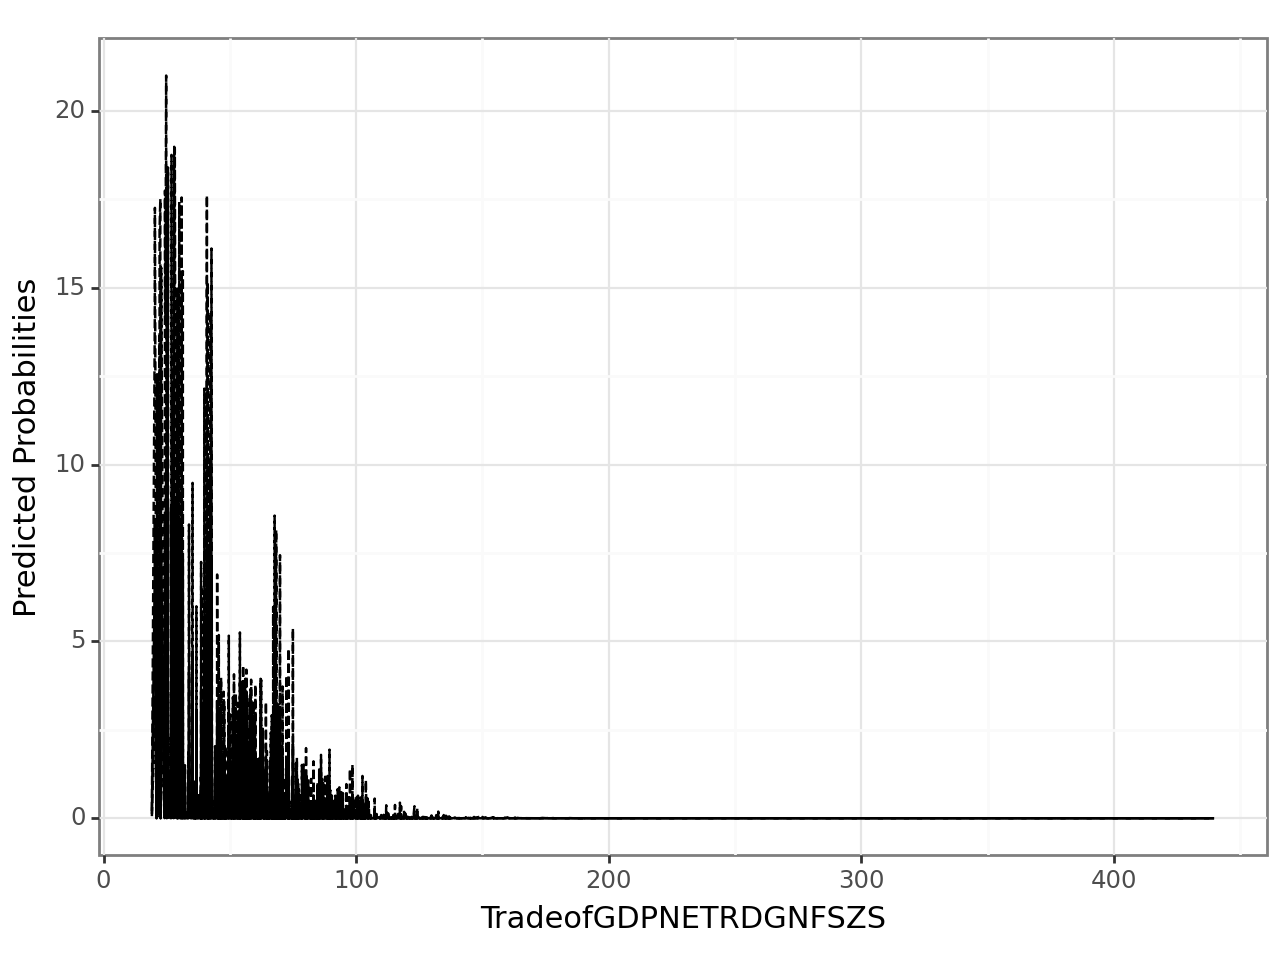

In [48]:
data_plot_asmnt4_TradeofGDPNETRDGNFSZS = assignment4_estimation.copy()
data_plot_asmnt4_TradeofGDPNETRDGNFSZS['polity'] = np.mean(data_plot_asmnt4_TradeofGDPNETRDGNFSZS['polity'])
data_plot_asmnt4_TradeofGDPNETRDGNFSZS['GDP_growth'] = np.mean(data_plot_asmnt4_TradeofGDPNETRDGNFSZS['GDP_growth'])
data_plot_asmnt4_TradeofGDPNETRDGNFSZS['FDI'] = np.mean(data_plot_asmnt4_TradeofGDPNETRDGNFSZS['FDI'])
data_plot_asmnt4_TradeofGDPNETRDGNFSZS['log_GDP_per_Capita'] = np.mean(data_plot_asmnt4_TradeofGDPNETRDGNFSZS['log_GDP_per_Capita'])

means_TradeofGDPNETRDGNFSZS = []
for x in range(0,8):
    means_TradeofGDPNETRDGNFSZS += [y for y in results_TradeofGDPNETRDGNFSZS.params[x]]

variance_covariance_TradeofGDPNETRDGNFSZS = results_TradeofGDPNETRDGNFSZS.cov_params()

sample_normal_TradeofGDPNETRDGNFSZS = np.random.multivariate_normal(means_TradeofGDPNETRDGNFSZS, variance_covariance_TradeofGDPNETRDGNFSZS, size = 1000)

coefficient_matrix_TradeofGDPNETRDGNFSZS = np.transpose(sample_normal_TradeofGDPNETRDGNFSZS[:,0:6])
matrix_values_TradeofGDPNETRDGNFSZS = 1 + np.exp(np.dot(data_plot_asmnt4_TradeofGDPNETRDGNFSZS[['Intercept', 'log_GDP_per_Capita', 'polity', 'GDP_growth', 'FDI', 'TradeofGDPNETRDGNFSZS']],
                                 coefficient_matrix_TradeofGDPNETRDGNFSZS))
for x in range(6, 43, 6):
    coefficient_matrix_TradeofGDPNETRDGNFSZS = np.transpose(sample_normal_TradeofGDPNETRDGNFSZS[:,x:x+6])
    matrix_current_TradeofGDPNETRDGNFSZS = np.exp(np.dot(data_plot_asmnt4_TradeofGDPNETRDGNFSZS[['Intercept', 'log_GDP_per_Capita', 'polity', 'GDP_growth', 'FDI', 'TradeofGDPNETRDGNFSZS']],
                                 coefficient_matrix_TradeofGDPNETRDGNFSZS))
    matrix_values_TradeofGDPNETRDGNFSZS += matrix_current_TradeofGDPNETRDGNFSZS

coefficient_matrix_TradeofGDPNETRDGNFSZS = np.transpose(sample_normal_TradeofGDPNETRDGNFSZS[:,42:48])
matrix_numerator_TradeofGDPNETRDGNFSZS = np.exp(np.dot(data_plot_asmnt4_TradeofGDPNETRDGNFSZS[['Intercept', 'log_GDP_per_Capita', 'polity', 'GDP_growth', 'FDI', 'TradeofGDPNETRDGNFSZS']],
                                 coefficient_matrix_TradeofGDPNETRDGNFSZS))

matrix_values_final_TradeofGDPNETRDGNFSZS = matrix_numerator_asmnt4/matrix_values_TradeofGDPNETRDGNFSZS

means_TradeofGDPNETRDGNFSZS = np.mean(matrix_values_final_TradeofGDPNETRDGNFSZS, axis = 1)
lb_TradeofGDPNETRDGNFSZS = np.percentile(matrix_values_final_TradeofGDPNETRDGNFSZS, q = 2.5, axis = 1)
ub_TradeofGDPNETRDGNFSZS = np.percentile(matrix_values_final_TradeofGDPNETRDGNFSZS, q = 97.5, axis = 1)

data_plotting_TradeofGDPNETRDGNFSZS = pd.DataFrame({'Predicted Probabilities': means_TradeofGDPNETRDGNFSZS,
                              'ub': ub_TradeofGDPNETRDGNFSZS,
                              'lb': lb_TradeofGDPNETRDGNFSZS,
                              'TradeofGDPNETRDGNFSZS': data_plot_asmnt4_TradeofGDPNETRDGNFSZS['TradeofGDPNETRDGNFSZS']})
plot_TradeofGDPNETRDGNFSZS = (ggplot(data_plotting_TradeofGDPNETRDGNFSZS, aes(x = 'TradeofGDPNETRDGNFSZS'))+
        geom_line(aes(y = 'Predicted Probabilities'), linetype = 'solid', colour = 'black')+
        geom_line(aes(y = 'ub'), linetype = 'dashed', colour = 'black') +
        geom_line(aes(y = 'lb'), linetype = 'dashed', colour = 'black') +
        theme_bw())
print(plot_TradeofGDPNETRDGNFSZS)

In [49]:
## V.

from scipy.stats import norm

from statsmodels.base.model import GenericLikelihoodModel
class MyOrderedProbit(GenericLikelihoodModel):
    def loglike(self, params):
        exog = self.exog
        endog = self.endog
        max_val = int(max(endog))
        log_likelihood = 0
        for x in range(max_val+1):
            b = endog == x
            if x == 0:
                log_likelihood += sum(np.log(norm.cdf(params[0] - np.dot(exog[b],params[max_val:]))))
            elif (x>0) and (x<max_val):
                log_likelihood += sum(np.log(norm.cdf(params[x] - np.dot(exog[b],params[max_val:])) -
                        norm.cdf(params[x-1] - np.dot(exog[b],params[max_val:]))))
            else:
                log_likelihood += sum(np.log(1- norm.cdf(params[x-1] - np.dot(exog[b],params[max_val:]))))
        return log_likelihood

In [50]:
model_ordered = sm.regression.linear_model.OLS.from_formula('physint ~ log_GDP_per_Capita + polity + GDP_growth + FDI',
                                                    data = assignment4_estimation)
results_ordered = model_ordered.fit()
starting_params_ordered = [results_ordered.params[0] + x*results_ordered.bse[0] for x in range(8)]
for x in results_ordered.params[1:]:
    starting_params_ordered += [x]
starting_params_ordered

[0.42013356565154175,
 0.6181210392747655,
 0.8161085128979891,
 1.014095986521213,
 1.2120834601444366,
 1.4100709337676602,
 1.608058407390884,
 1.8060458810141076,
 0.48127100894170355,
 0.1028552435027037,
 -0.022078914318416683,
 0.02085523060038242]

In [51]:
model_probit = MyOrderedProbit(endog = assignment4_estimation['physint'],
                       exog = assignment4_estimation[['log_GDP_per_Capita', 'polity', 'GDP_growth', 'FDI']])
results_probit = model_probit.fit(start_params = starting_params_ordered, method = 'newton')

print(results_probit.summary(xname = ['tau1', 'tau2', 'tau3', 'tau4', 'tau5', 'tau6', 'tau7', 'tau8',
                               'log_GDP_per_Capita', 'polity', 'GDP_growth', 'FDI']))
log_likelihood_nested = results_probit.llf

Optimization terminated successfully.
         Current function value: 1.879794
         Iterations 8
                           MyOrderedProbit Results                            
Dep. Variable:                physint   Log-Likelihood:                -4229.5
Model:                MyOrderedProbit   AIC:                             8481.
Method:            Maximum Likelihood   BIC:                             8544.
Date:                Wed, 27 Mar 2024                                         
Time:                        18:49:38                                         
No. Observations:                2250                                         
Df Residuals:                    2246                                         
Df Model:                           3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
tau1         

/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:2750: UserWarning: df_model + k_constant + k_extra differs from k_params
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:2754: UserWarning: df_resid differs from nobs - k_params


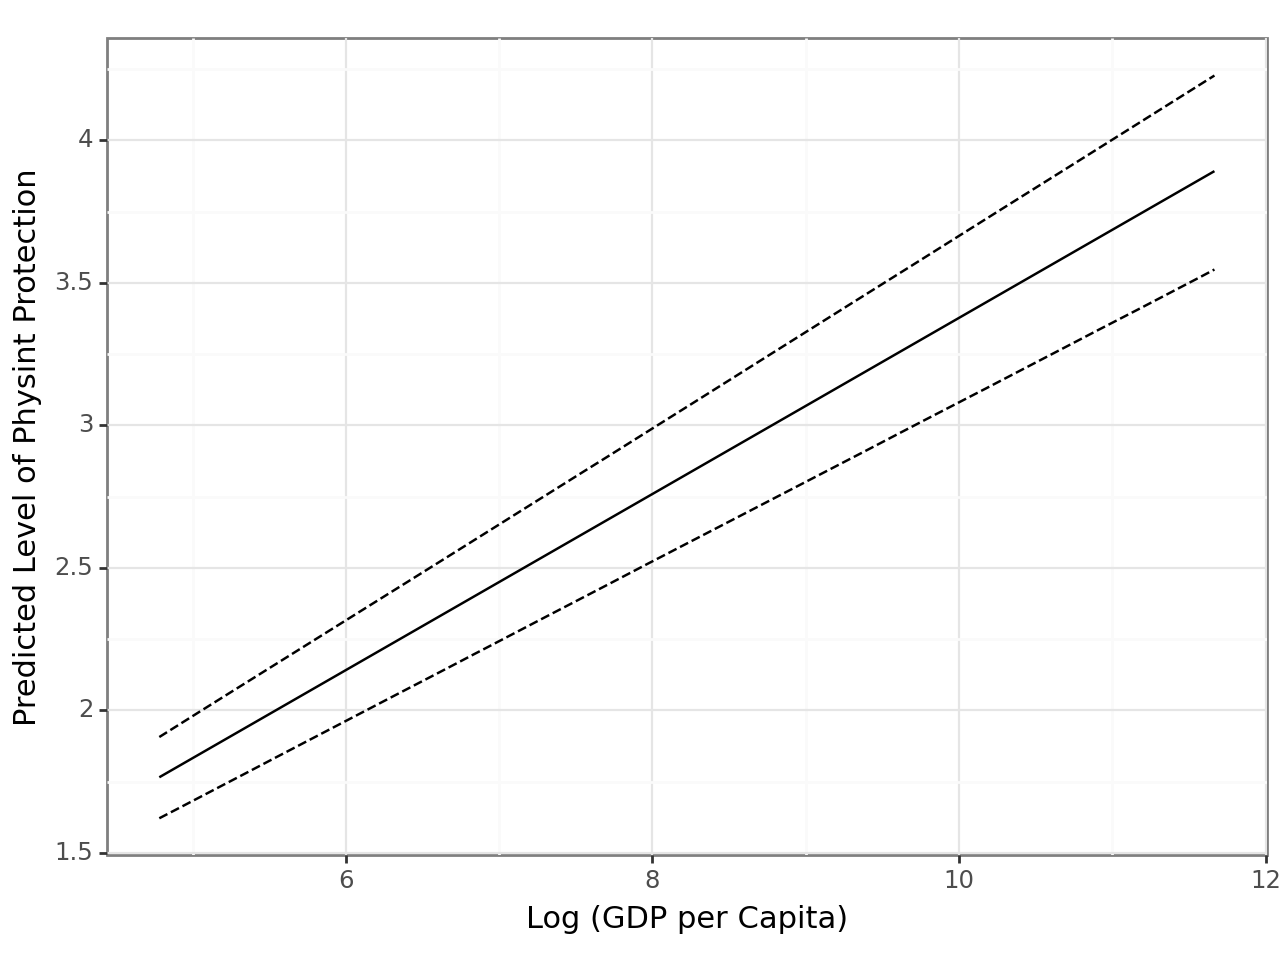

<Figure Size: (640 x 480)>

In [52]:
variance_covariance_probit = results_probit.cov_params()

coef_distribution_probit = np.random.multivariate_normal(results_probit.params,variance_covariance_probit,size=10000)

coef_distribution_probit = coef_distribution_probit[:,8:]
data_plot_probit = assignment4_estimation.copy()
data_plot_probit['GDP_growth'] = np.mean(data_plot_probit['GDP_growth'])
data_plot_probit['polity'] = np.mean(data_plot_probit['polity'])
data_plot_probit['FDI'] = np.mean(data_plot_probit['FDI'])

matrix_score_probit = np.dot(data_plot_probit[['log_GDP_per_Capita', 'polity', 'GDP_growth', 'FDI']], np.transpose(coef_distribution_probit))
means_probit = np.mean(matrix_score_probit, axis = 1)
upper_bound_probit = np.percentile(matrix_score_probit, axis = 1, q = 97.5)
lower_bound_probit = np.percentile(matrix_score_probit, axis = 1, q = 2.5)
data_illustration_probit = pd.DataFrame({'Log (GDP per Capita)': data_plot_probit['log_GDP_per_Capita'],
                                  'Predicted Level of Physint Protection': means_probit,
                                  'Upper Bound': upper_bound_probit,
                                  'Lower Bound': lower_bound_probit})
plot_probit = (ggplot(data_illustration_probit, aes(x = 'Log (GDP per Capita)'))+
        geom_line(aes(y = 'Predicted Level of Physint Protection'), linetype = 'solid', colour = 'black') +
        geom_line(aes(y = 'Upper Bound'), linetype = 'dashed', colour = 'black') +
        geom_line(aes(y = 'Lower Bound'), linetype = 'dashed', colour = 'black') +
        theme_bw())
plot_probit

In [57]:
## VI.

print("In countries with higher GDP per capita, the probability that physical integrity rights will be protected is bigger than in \"poorer\" countries in term of GDP per capita. That is, probability grows with growth in GDP per capita. This may be due to the fact that in countries with higher GDP per capita people have more money to protect their rights in general, like hiring better lawyers, but more importantly that may be due to the fact that in countries where rights in general are protected better economies develop better, if we take GDP per capita as one of the measures for economic development (for instance, China has a very astonishing pace of economic growth, but a relatively small GDP per capita as well as troubles with individual rights' protection)")

In countries with higher GDP per capita, the probability that physical integrity rights will be protected is bigger than in "poorer" countries in term of GDP per capita. That is, probability grows with growth in GDP per capita. This may be due to the fact that in countries with higher GDP per capita people have more money to protect their rights in general, like hiring better lawyers, but more importantly that may be due to the fact that in countries where rights in general are protected better economies develop better, if we take GDP per capita as one of the measures for economic development (for instance, China has a very astonishing pace of economic growth, but a relatively small GDP per capita as well as troubles with individual rights' protection)
